In [10]:
# confirm columns

import pandas as pd

balanced_bgg = pd.read_csv("../../data/new/balanced_bgg.csv")
balanced_desc = pd.read_csv("../../data/new/balanced_desc_only.csv")

print("balanced_bgg shape:", balanced_bgg.shape)
print(balanced_bgg.columns.tolist())
display(balanced_bgg.head())

print("balanced_desc_only shape:", balanced_desc.shape)
print(balanced_desc.columns.tolist())
display(balanced_desc.head())

balanced_bgg shape: (5000, 8)
['Unnamed: 0', 'name', 'description', 'boardgamecategory', 'boardgamemechanic', 'Average', 'number_of_reviews', 'class']


,Unnamed: 0,name,description,boardgamecategory,boardgamemechanic,Average,number_of_reviews,class
0,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
1,16246,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...","['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",1.04,75,1
2,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
3,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
4,16246,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...","['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",1.04,75,1


balanced_desc_only shape: (8193, 3)
['Unnamed: 0', 'name', 'description_x']


,Unnamed: 0,name,description_x
0,0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
1,1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ..."
2,2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
3,3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
4,4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ..."


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import html
import contractions
import nltk
import pickle
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
# load the balanced dataset

balanced_df = pd.read_csv("../../data/new/balanced_bgg.csv")

print("Balanced dataset shape:", balanced_df.shape)
print("Columns:", balanced_df.columns.tolist())

balanced_df.head()

Balanced dataset shape: (5000, 8)
Columns: ['Unnamed: 0', 'name', 'description', 'boardgamecategory', 'boardgamemechanic', 'Average', 'number_of_reviews', 'class']


,Unnamed: 0,name,description,boardgamecategory,boardgamemechanic,Average,number_of_reviews,class
0,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
1,16246,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...","['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",1.04,75,1
2,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
3,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
4,16246,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...","['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",1.04,75,1


In [13]:
# clean basic columns 

balanced_df = balanced_df.dropna(subset=["name", "description"]).copy()

balanced_df["name"] = balanced_df["name"].astype(str)
balanced_df["description"] = balanced_df["description"].astype(str)

balanced_df = balanced_df[balanced_df["description"].str.strip() != ""].copy()

balanced_df["Average"] = pd.to_numeric(balanced_df["Average"], errors="coerce")
balanced_df["number_of_reviews"] = pd.to_numeric(balanced_df["number_of_reviews"], errors="coerce")

print("Cleaned balanced shape:", balanced_df.shape)
balanced_df.head()

Cleaned balanced shape: (5000, 8)


,Unnamed: 0,name,description,boardgamecategory,boardgamemechanic,Average,number_of_reviews,class
0,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
1,16246,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...","['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",1.04,75,1
2,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
3,24389,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,['Action / Dexterity'],['Rock-Paper-Scissors'],1.31,31,1
4,16246,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...","['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",1.04,75,1


In [14]:
# This cell defines the best preprocessing function from the previous SVD experiments.
# It cleans each game description before TF-IDF.
#
# Steps:
# 1. Fix HTML symbols like &quot;
# 2. Expand contractions like "don't" -> "do not"
# 3. Lowercase the text
# 4. Split text into words
# 5. Remove stopwords like "the", "and", "is"
# 6. Lemmatize words to their base form
# 7. Keep only alphabetic words
# 8. Remove very short words

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_nltk_alpha_only(text):
    text = html.unescape(str(text))
    text = contractions.fix(text)

    tokens = word_tokenize(text.lower())

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [15]:
# This cell takes all game descriptions from the balanced dataset
# and applies the preprocessing function to each one.

descs = balanced_df["description"].astype(str).tolist()

processed_corpus_alpha = [
    preprocess_nltk_alpha_only(doc)
    for doc in descs
]

print("Number of processed descriptions:", len(processed_corpus_alpha))

# Show the first 3 cleaned descriptions to check if preprocessing worked.
processed_corpus_alpha[:3]

Number of processed descriptions: 5000


['pressman take classic game put exciting console plus even player play time turn wheel pick rock paper scissors flip reveal shield score point player beat special game hub included play',
 'show good loser show real loser oneupmanship satirical board game player struggle money power ego winner first player earn mean possible playing stock market building skyscraper gambling collecting trophy',
 'pressman take classic game put exciting console plus even player play time turn wheel pick rock paper scissors flip reveal shield score point player beat special game hub included play']

In [16]:
# This cell turns the cleaned text into TF-IDF vectors.
# TF-IDF converts words into numerical features.
#
# Then it applies SVD to reduce the number of features.
# We cap the number of SVD components at 5000, as Qucumber suggested.

tfidf_vectorizer_balanced = TfidfVectorizer(
    token_pattern=r"\w+",
    lowercase=True,
    min_df=5,
)

X_tfidf_balanced = tfidf_vectorizer_balanced.fit_transform(processed_corpus_alpha)

print("TF-IDF shape:", X_tfidf_balanced.shape)

# Make sure n_components does not exceed the number of rows or features.
max_components = min(
    5000,
    X_tfidf_balanced.shape[0] - 1,
    X_tfidf_balanced.shape[1] - 1
)

svd_balanced = TruncatedSVD(
    n_components=max_components,
    random_state=42
)

svd_balanced.fit(X_tfidf_balanced)

print("SVD fitted with components:", max_components)

TF-IDF shape: (5000, 6205)
SVD fitted with components: 4999


In [17]:
# This cell checks how many singular values/components are needed
# to reach 90% explained variance.
#
# The goal is to find the smallest number of SVs that still preserves
# about 90% of the information from the TF-IDF matrix.

energy_balanced = svd_balanced.singular_values_**2
energy_ratio_balanced = energy_balanced / energy_balanced.sum()
energy_ratio_cumsum_balanced = energy_ratio_balanced.cumsum()

balanced_svs = None

for i in range(len(energy_ratio_cumsum_balanced)):
    if energy_ratio_cumsum_balanced[i] >= 0.90:
        balanced_svs = i + 1
        print(f"Explained variance at {balanced_svs} SVs: {energy_ratio_cumsum_balanced[i]:.2f}")
        break

if balanced_svs is None:
    print(f"Did not reach 0.90. Max explained variance: {energy_ratio_cumsum_balanced[-1]:.2f}")

Explained variance at 998 SVs: 0.90


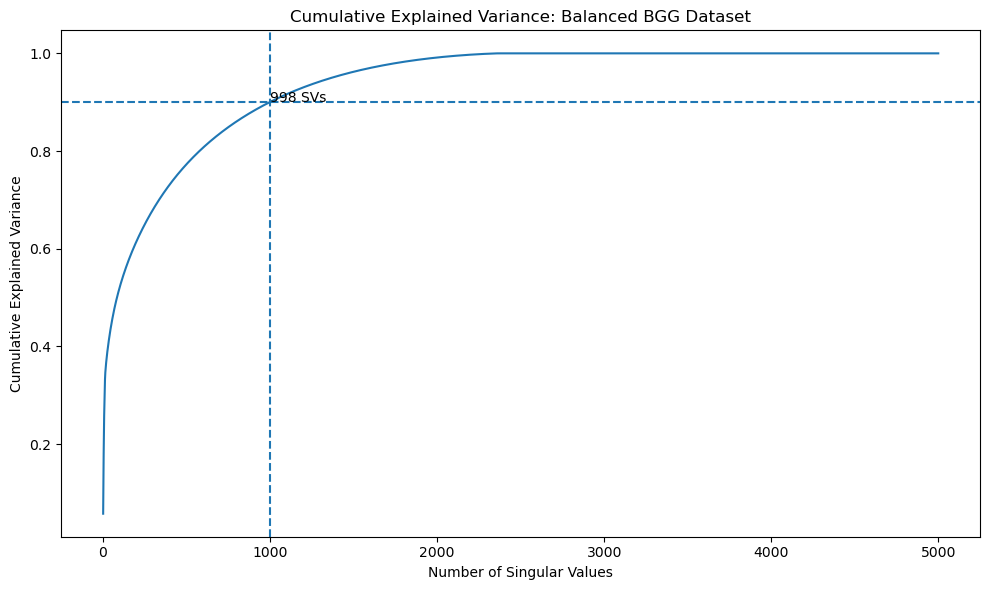

In [18]:
# This cell plots the cumulative explained variance.
# The horizontal dashed line shows the 90% target.
# The vertical dashed line shows how many SVs were needed to reach 90%.

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(energy_ratio_cumsum_balanced) + 1),
    energy_ratio_cumsum_balanced
)

plt.axhline(0.90, linestyle="--")

if balanced_svs is not None:
    plt.axvline(balanced_svs, linestyle="--")
    plt.text(balanced_svs, 0.90, f"{balanced_svs} SVs")

plt.title("Cumulative Explained Variance: Balanced BGG Dataset")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [19]:
# This cell creates the final SVD feature table for training.
#
# It transforms the TF-IDF matrix into SVD vectors,
# keeps only the threshold number of SVs needed for 90% variance,
# then combines those SVD features with useful original columns.
#
# This CSV can be used later for model training.

final_n_svs = balanced_svs

X_svd_balanced_final = svd_balanced.transform(X_tfidf_balanced)[:, :final_n_svs]

svd_balanced_table = pd.DataFrame(
    X_svd_balanced_final,
    columns=[f"SV_{i+1}" for i in range(final_n_svs)]
)

svd_balanced_table = pd.concat(
    [
        balanced_df[[
            "name",
            "Average",
            "number_of_reviews",
            "class",
            "boardgamecategory",
            "boardgamemechanic"
        ]].reset_index(drop=True),
        svd_balanced_table.reset_index(drop=True)
    ],
    axis=1
)

svd_balanced_table.to_csv("balanced_svd_table.csv", index=False)

print("Balanced SVD table shape:", svd_balanced_table.shape)
svd_balanced_table.head()

Balanced SVD table shape: (5000, 1004)


,name,Average,number_of_reviews,class,boardgamecategory,boardgamemechanic,SV_1,SV_2,SV_3,SV_4,...,SV_989,SV_990,SV_991,SV_992,SV_993,SV_994,SV_995,SV_996,SV_997,SV_998
0,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],0.180557,-0.068886,0.598678,0.18629,...,-0.000026,0.000151,0.000064,0.000058,-0.000147,0.000030,-0.000101,0.000129,0.000019,-0.000011
1,Oneupmanship: Mine's Bigger,1.04,75,1,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",0.143434,-0.065287,0.388869,-0.66626,...,0.000109,-0.000020,-0.000129,0.000087,0.000176,0.000027,0.000177,0.000001,-0.000032,0.000040
2,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],0.180557,-0.068886,0.598678,0.18629,...,-0.000026,0.000151,0.000064,0.000058,-0.000147,0.000030,-0.000101,0.000129,0.000019,-0.000011
3,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],0.180557,-0.068886,0.598678,0.18629,...,-0.000026,0.000151,0.000064,0.000058,-0.000147,0.000030,-0.000101,0.000129,0.000019,-0.000011
4,Oneupmanship: Mine's Bigger,1.04,75,1,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",0.143434,-0.065287,0.388869,-0.66626,...,0.000109,-0.000020,-0.000129,0.000087,0.000176,0.000027,0.000177,0.000001,-0.000032,0.000040


## Balanced Dataset SVD Result

Using the balanced BGG dataset, the TF-IDF matrix produced 6,205 features across 5,000 games. After applying TruncatedSVD with a maximum of 4,999 components, the model reached 0.90 explained variance at 998 singular values. Therefore, the final balanced SVD table keeps the first 998 SVD components for training.